In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load datasets
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

movies = movies.merge(credits, left_on='id', right_on='movie_id')

print("Shape:", movies.shape)
print("\nColumns:", movies.columns.tolist())
movies.head(3)

Shape: (4803, 24)

Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average', 'vote_count', 'movie_id', 'title_y', 'cast', 'crew']


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [13]:
# Keep only relevant columns
movies = movies[['title', 'budget', 'revenue', 'genres', 
                 'release_date', 'vote_average', 'vote_count',
                 'runtime', 'popularity']]

# Remove rows where budget or revenue is 0
movies = movies[(movies['budget'] > 0) & (movies['revenue'] > 0)]

# Extract year and month from release date
movies['release_date'] = pd.to_datetime(movies['release_date'])
movies['year'] = movies['release_date'].dt.year
movies['month'] = movies['release_date'].dt.month
movies['month_name'] = movies['release_date'].dt.strftime('%B')

# Calculate ROI (Return on Investment)
movies['roi'] = ((movies['revenue'] - movies['budget']) / movies['budget']) * 100

# Extract genre names from JSON-like column
def extract_genres(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return [g['name'] for g in genres]
    except:
        return []

movies['genres_list'] = movies['genres'].apply(extract_genres)

# Remove ROI outliers
movies = movies[movies['roi'] < 10000]

print("Clean dataset shape:", movies.shape)
print("\nSample ROI values:")
print(movies[['title', 'budget', 'revenue', 'roi']].head())

Clean dataset shape: (3204, 14)

Sample ROI values:
                                      title     budget     revenue  \
0                                    Avatar  237000000  2787965087   
1  Pirates of the Caribbean: At World's End  300000000   961000000   
2                                   Spectre  245000000   880674609   
3                     The Dark Knight Rises  250000000  1084939099   
4                               John Carter  260000000   284139100   

           roi  
0  1076.356577  
1   220.333333  
2   259.459024  
3   333.975640  
4     9.284269  


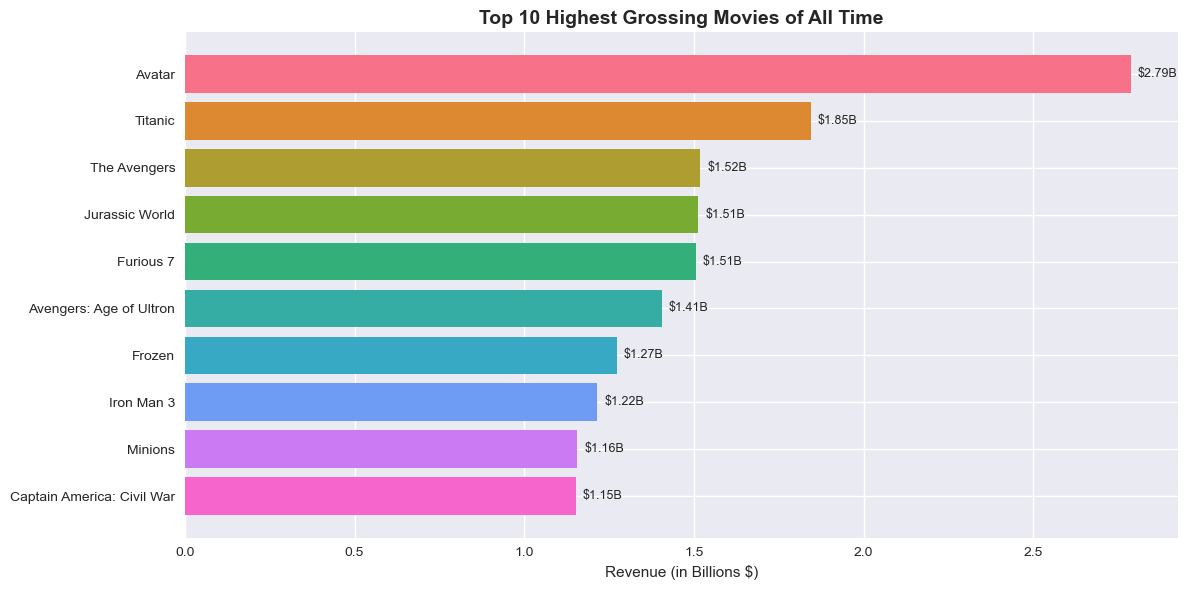

Chart saved!


In [14]:
# Top 10 highest grossing movies
top10 = movies.nlargest(10, 'revenue')[['title', 'revenue', 'budget', 'roi']]

plt.figure(figsize=(12, 6))
bars = plt.barh(top10['title'], top10['revenue'] / 1e9, color=sns.color_palette("husl", 10))
plt.xlabel('Revenue (in Billions $)')
plt.title('Top 10 Highest Grossing Movies of All Time', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for bar, val in zip(bars, top10['revenue'] / 1e9):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'${val:.2f}B', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top10_movies.png', dpi=150)
plt.show()
print("Chart saved!")

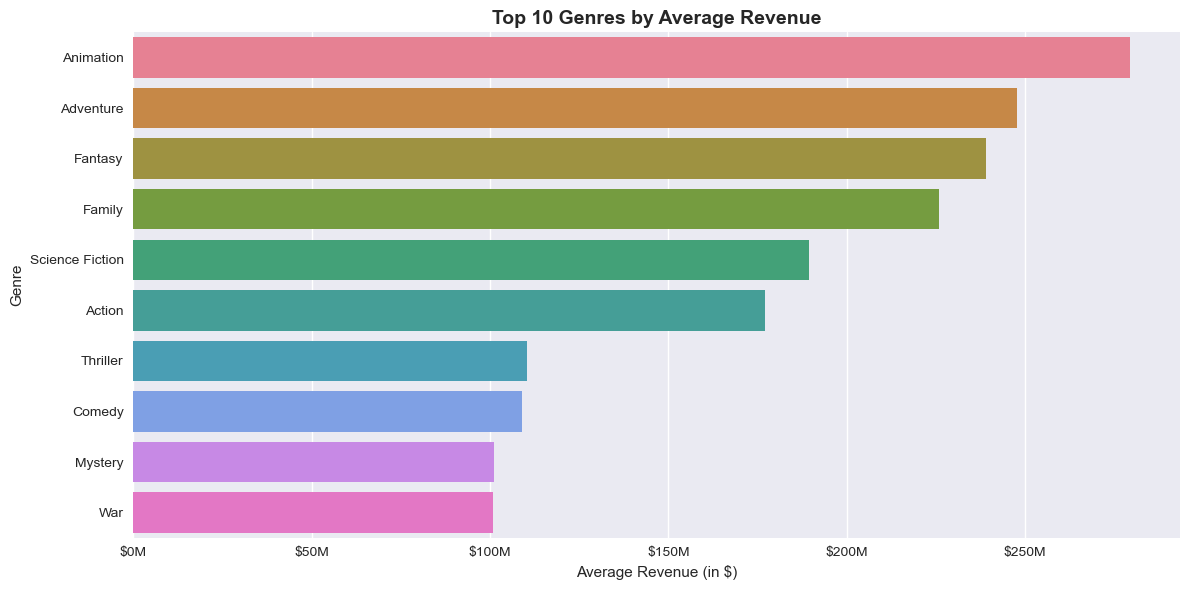

Chart saved!


In [15]:
# Explode genres so each movie-genre pair is a separate row
from collections import defaultdict

genre_revenue = defaultdict(list)

for _, row in movies.iterrows():
    for genre in row['genres_list']:
        genre_revenue[genre].append(row['revenue'])

# Calculate average revenue per genre
genre_avg = {genre: sum(revenues)/len(revenues) 
             for genre, revenues in genre_revenue.items()}

genre_df = pd.DataFrame(list(genre_avg.items()), 
                        columns=['Genre', 'Avg_Revenue'])
genre_df = genre_df.sort_values('Avg_Revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=genre_df, x='Avg_Revenue', y='Genre', palette='husl')
plt.xlabel('Average Revenue (in $)')
plt.title('Top 10 Genres by Average Revenue', fontsize=14, fontweight='bold')

# Format x-axis in millions
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('genre_revenue.png', dpi=150)
plt.show()
print("Chart saved!")

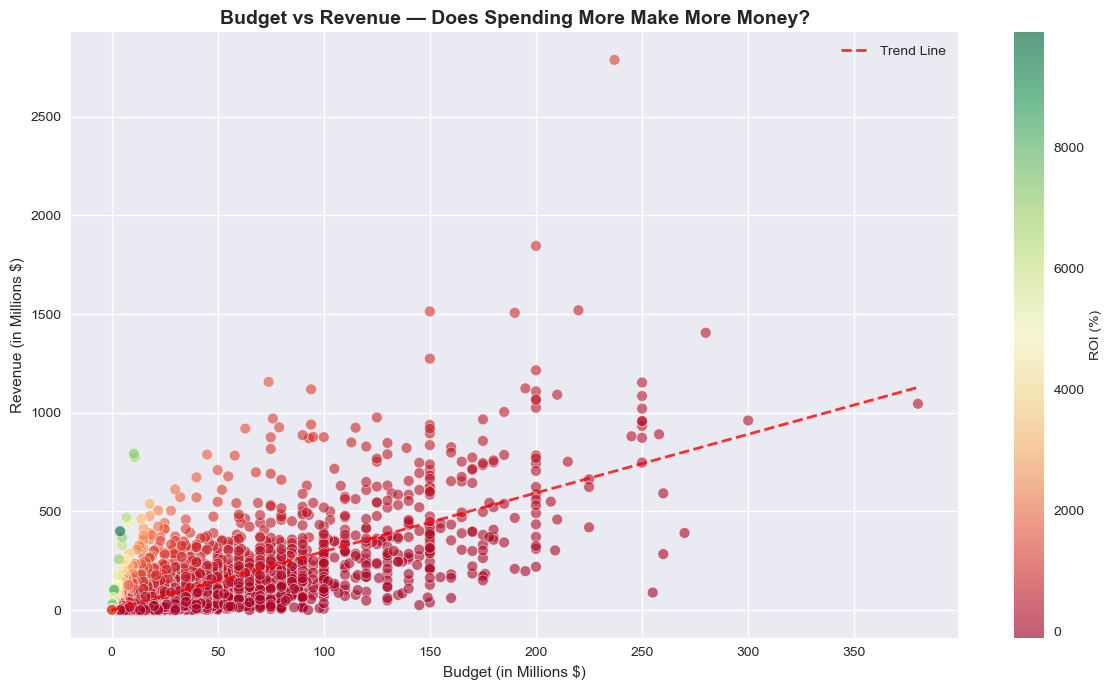

Chart saved!


In [16]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(movies['budget'] / 1e6, 
                      movies['revenue'] / 1e6,
                      c=movies['roi'], 
                      cmap='RdYlGn',
                      alpha=0.6, 
                      edgecolors='white',
                      linewidth=0.5,
                      s=60)

# Colorbar to show ROI
cbar = plt.colorbar(scatter)
cbar.set_label('ROI (%)', fontsize=10)

# Add trend line
z = np.polyfit(movies['budget'] / 1e6, movies['revenue'] / 1e6, 1)
p = np.poly1d(z)
x_line = sorted(movies['budget'] / 1e6)
plt.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Trend Line')

plt.xlabel('Budget (in Millions $)', fontsize=11)
plt.ylabel('Revenue (in Millions $)', fontsize=11)
plt.title('Budget vs Revenue — Does Spending More Make More Money?', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('budget_vs_revenue.png', dpi=150)
plt.show()
print("Chart saved!")

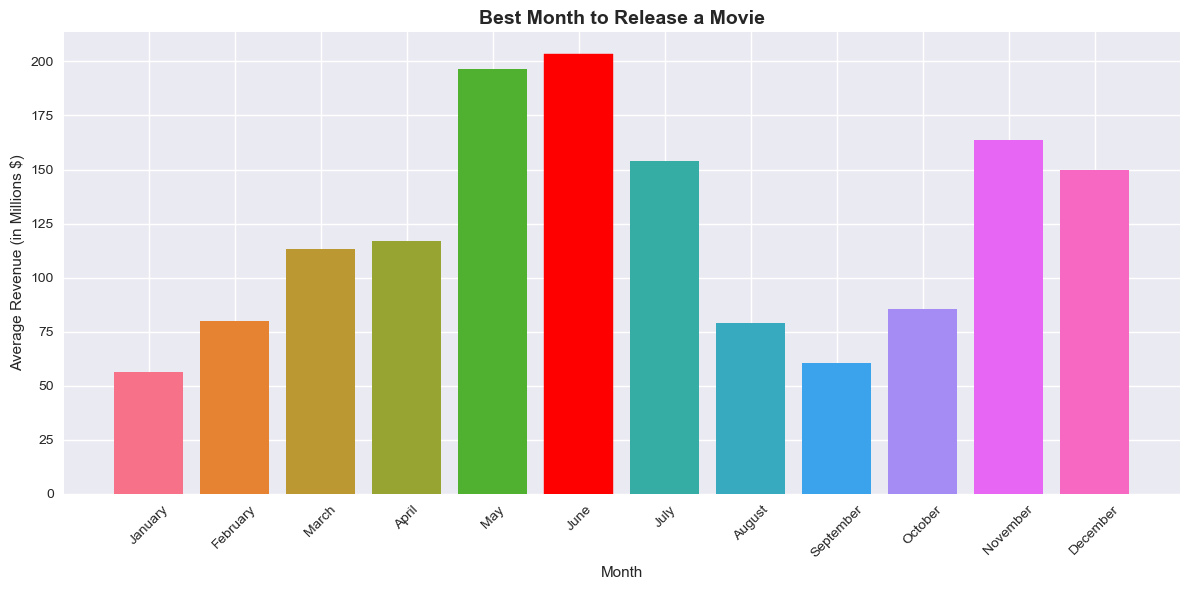

Chart saved!


In [17]:
# Average revenue by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

month_revenue = movies.groupby('month_name')['revenue'].mean().reindex(month_order)

plt.figure(figsize=(12, 6))
bars = plt.bar(month_order, month_revenue / 1e6, 
               color=sns.color_palette("husl", 12))

plt.xlabel('Month', fontsize=11)
plt.ylabel('Average Revenue (in Millions $)', fontsize=11)
plt.title('Best Month to Release a Movie', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Highlight the highest bar
max_idx = list(month_revenue).index(max(month_revenue))
bars[max_idx].set_color('red')

plt.tight_layout()
plt.savefig('best_month.png', dpi=150)
plt.show()
print("Chart saved!")

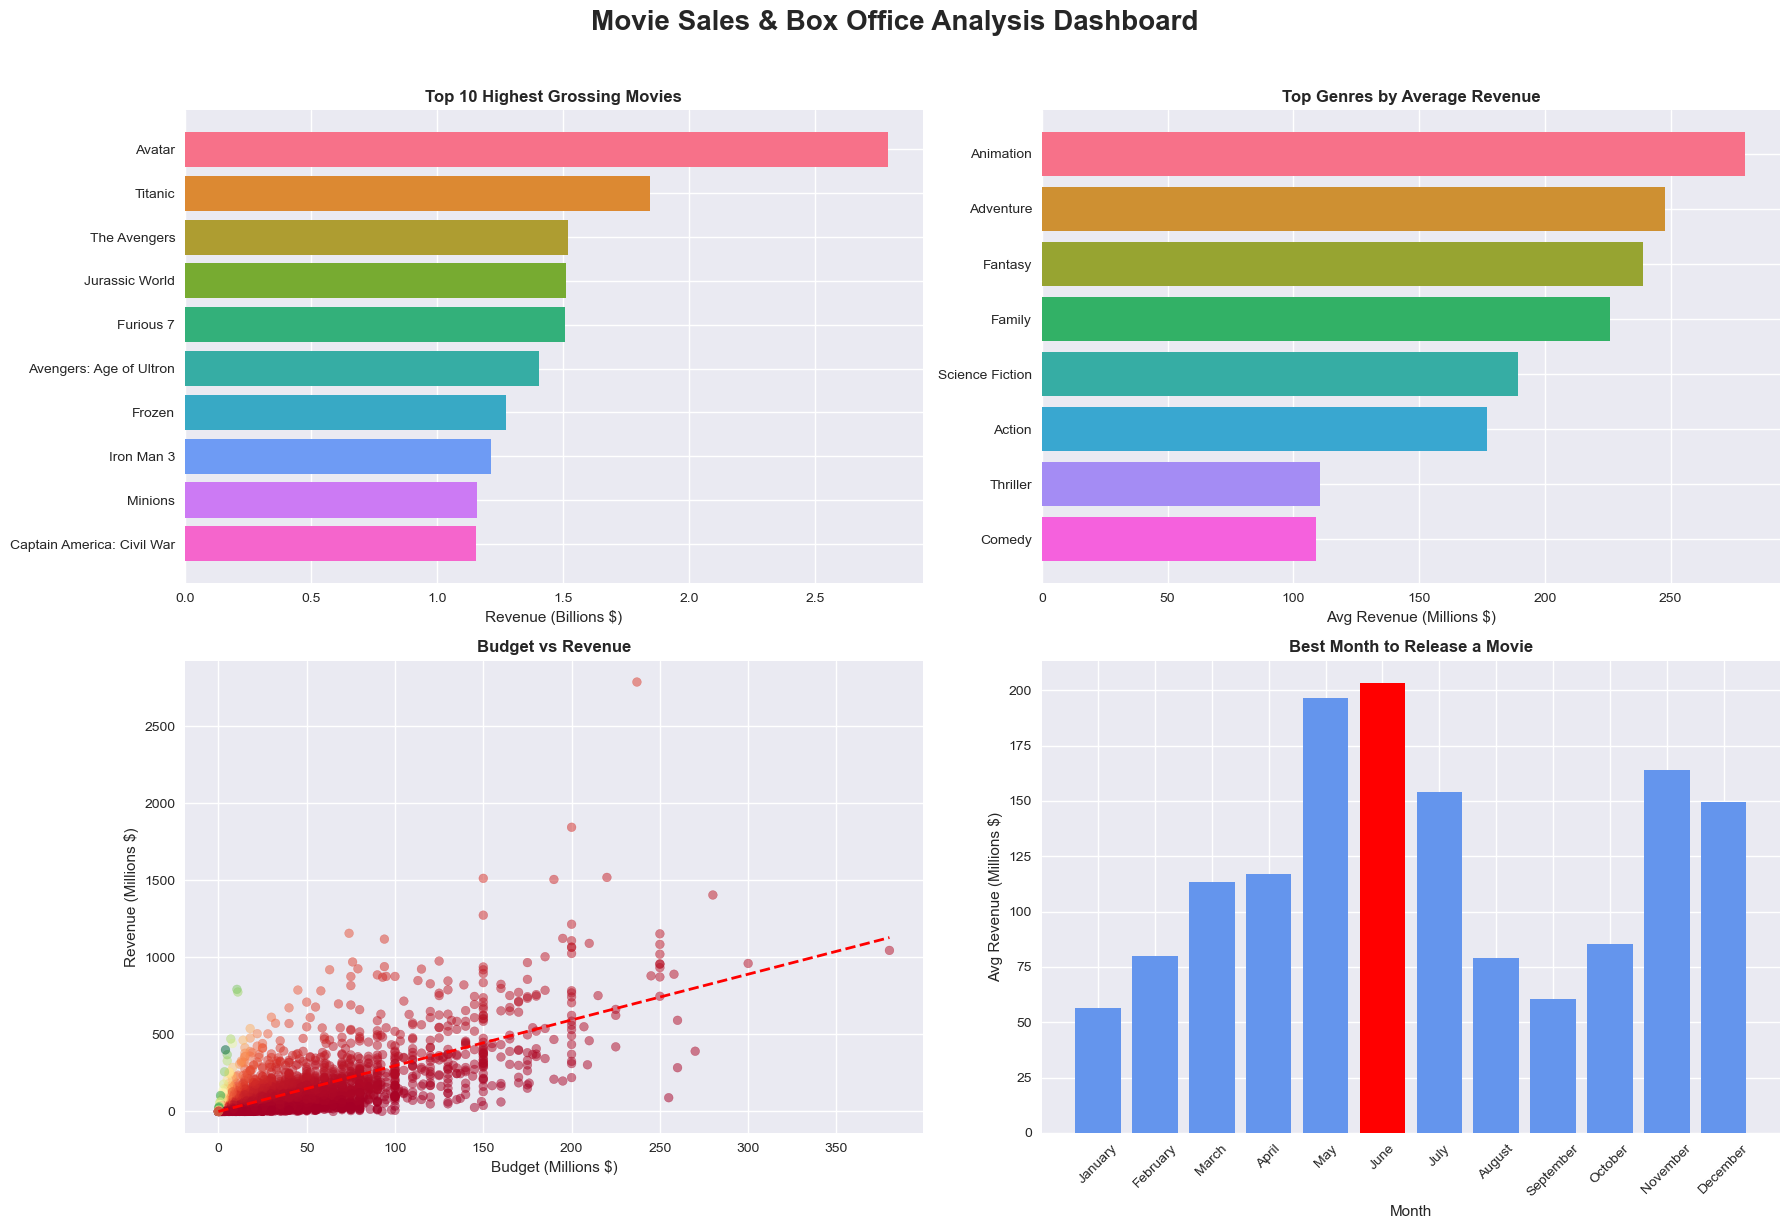

Dashboard saved!


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Movie Sales & Box Office Analysis Dashboard', 
             fontsize=20, fontweight='bold', y=1.02)

# --- Chart 1: Top 10 Highest Grossing Movies ---
top10 = movies.nlargest(10, 'revenue')[['title', 'revenue']]
axes[0, 0].barh(top10['title'], top10['revenue'] / 1e9,
                color=sns.color_palette("husl", 10))
axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel('Revenue (Billions $)')
axes[0, 0].set_title('Top 10 Highest Grossing Movies', fontweight='bold')

# --- Chart 2: Top Genres by Revenue ---
genre_df_top = genre_df.head(8)
axes[0, 1].barh(genre_df_top['Genre'], 
                genre_df_top['Avg_Revenue'] / 1e6,
                color=sns.color_palette("husl", 8))
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Avg Revenue (Millions $)')
axes[0, 1].set_title('Top Genres by Average Revenue', fontweight='bold')

# --- Chart 3: Budget vs Revenue ---
axes[1, 0].scatter(movies['budget'] / 1e6,
                   movies['revenue'] / 1e6,
                   c=movies['roi'], cmap='RdYlGn',
                   alpha=0.5, s=40)
z = np.polyfit(movies['budget'] / 1e6, movies['revenue'] / 1e6, 1)
p = np.poly1d(z)
x_line = sorted(movies['budget'] / 1e6)
axes[1, 0].plot(x_line, p(x_line), "r--", linewidth=2)
axes[1, 0].set_xlabel('Budget (Millions $)')
axes[1, 0].set_ylabel('Revenue (Millions $)')
axes[1, 0].set_title('Budget vs Revenue', fontweight='bold')

# --- Chart 4: Best Month to Release ---
colors = ['red' if m == 'June' else '#6495ED' for m in month_order]
axes[1, 1].bar(month_order, month_revenue / 1e6, color=colors)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Avg Revenue (Millions $)')
axes[1, 1].set_title('Best Month to Release a Movie', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('movie_analysis_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

In [19]:
print("=" * 55)
print("   MOVIE SALES & BOX OFFICE ANALYSIS — SUMMARY")
print("=" * 55)

print(f"\n📊 Total Movies Analyzed: {len(movies):,}")
print(f"📅 Year Range: {int(movies['year'].min())} - {int(movies['year'].max())}")

top_movie = movies.loc[movies['revenue'].idxmax(), 'title']
print(f"\n🏆 Highest Grossing Movie: {top_movie}")

top_genre = genre_df.iloc[0]['Genre']
print(f"🎬 Most Profitable Genre: {top_genre}")

print(f"\n📅 Best Month to Release: June")

best_roi = movies.loc[movies['roi'].idxmax(), ['title', 'roi']]
print(f"💰 Best ROI Movie: {best_roi['title']} ({best_roi['roi']:.0f}% ROI)")

avg_budget = movies['budget'].mean() / 1e6
avg_revenue = movies['revenue'].mean() / 1e6
print(f"\n💵 Average Budget: ${avg_budget:.1f}M")
print(f"💵 Average Revenue: ${avg_revenue:.1f}M")
print(f"📈 Average ROI: {movies['roi'].mean():.1f}%")
print("=" * 55)

   MOVIE SALES & BOX OFFICE ANALYSIS — SUMMARY

📊 Total Movies Analyzed: 3,204
📅 Year Range: 1916 - 2016

🏆 Highest Grossing Movie: Avatar
🎬 Most Profitable Genre: Animation

📅 Best Month to Release: June
💰 Best ROI Movie: Gone with the Wind (9904% ROI)

💵 Average Budget: $41.0M
💵 Average Revenue: $121.6M
📈 Average ROI: 321.4%
